# Análisis de Ventas por Categoría de Producto

## Autor: Agustín Pluda

## Descripción

Este notebook continúa el trabajo de `product_classifier.ipynb`, donde se construyó un modelo de Machine Learning para clasificar los productos del catálogo de Online Retail II en categorías comerciales.

Acá se toma el catálogo ya categorizado (`data/processed/products_categorized.csv`) y se lo cruza contra las transacciones originales para analizar el comportamiento de las ventas según categoría: participación en el revenue, estacionalidad, ticket promedio, mix por país y productos destacados dentro de cada categoría.

## 0. Importación de librerías

In [188]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
%matplotlib inline

## 1. Carga de datos

### 1.1 Transacciones y catálogo categorizado

In [189]:
transacciones = pd.read_csv("data/main/online_retail_sales.csv")
catalogo = pd.read_csv("data/processed/products_categorized.csv")

print(f"Transacciones: {transacciones.shape}")
print(f"Catalogo     : {catalogo.shape}")

catalogo["categoria_final"].value_counts()

Transacciones: (1003417, 12)
Catalogo     : (4724, 14)


categoria_final
Cocina y Mesa                          860
Sin clasificar                         730
Papelería y Tarjetería                 472
Velas e Iluminación                    447
Joyería y Bijouterie                   396
Decoración del Hogar                   267
Navidad                                244
Cajas y Almacenamiento                 238
Bolsos y Carteras                      228
Espejos, Relojes y Arte de Pared       189
Pascua y Fiestas                       155
Textiles del Hogar                     150
Jardín y Exterior                      129
Marcos y Fotografía                     95
Carteles y Señalética                   76
Botellas de Agua Caliente y Confort     48
Name: count, dtype: int64

## 2. Merge con las categorías

### 2.1 Merge por `stock_code` normalizado

In [190]:
transacciones["stock_code"] = transacciones["stock_code"].str.strip().str.upper()

df_con_categoria = transacciones.merge(
    catalogo[["stock_code", "categoria_final"]],
    on="stock_code",
    how="left",
)

print(f"Filas originales: {len(transacciones):,}")
print(f"Filas post-merge: {len(df_con_categoria):,}")
print(f"Diferencia      : {len(df_con_categoria) - len(transacciones)}")

print(f"Sin categoria (vouchers u otros no catalogados): {df_con_categoria['categoria_final'].isna().sum()}")
df_con_categoria.loc[df_con_categoria["categoria_final"].isna(), "categoria_final"] = "Sin categorizar (voucher/otro)"

Filas originales: 1,003,417
Filas post-merge: 1,003,417
Diferencia      : 0
Sin categoria (vouchers u otros no catalogados): 77


### 2.2 Verificación de cierre de revenue

In [191]:
revenue_por_categoria = df_con_categoria.groupby("categoria_final")["total_price"].sum().sort_values(ascending=False)

print(f"Revenue total (transacciones)     : {transacciones['total_price'].sum():,.2f}")
print(f"Revenue total (suma por categoria): {revenue_por_categoria.sum():,.2f}")

revenue_por_categoria

Revenue total (transacciones)     : 19,645,617.79
Revenue total (suma por categoria): 19,645,617.79


categoria_final
Cocina y Mesa                          4490145.95
Bolsos y Carteras                      2017224.44
Papelería y Tarjetería                 1661688.74
Sin clasificar                         1652964.02
Velas e Iluminación                    1652434.17
Cajas y Almacenamiento                 1478892.06
Decoración del Hogar                   1332728.29
Textiles del Hogar                      951579.37
Navidad                                 924183.34
Pascua y Fiestas                        754055.40
Botellas de Agua Caliente y Confort     692074.23
Jardín y Exterior                       552178.58
Carteles y Señalética                   539207.58
Espejos, Relojes y Arte de Pared        433733.45
Marcos y Fotografía                     376418.14
Joyería y Bijouterie                    134353.86
Sin categorizar (voucher/otro)            1756.17
Name: total_price, dtype: float64

## 3. Revenue y unidades por categoría

### 3.1 Paleta y tabla resumen

In [192]:
COLOR_SEQ = "#2a78d6"      # azul: metrica de magnitud (revenue, unidades)
COLOR_MUTED = "#898781"    # gris: para "Sin categorizar" (no es una categoria real)
COLOR_GRID = "#e1e0d9"
COLOR_AXIS = "#c3c2b7"
COLOR_INK = "#0b0b0b"
COLOR_INK_SEC = "#52514e"

resumen_categoria = (
    df_con_categoria.groupby("categoria_final")
    .agg(
        revenue=("total_price", "sum"),
        unidades=("quantity", "sum"),
        transacciones=("invoice", "count"),
    )
    .assign(
        participacion=lambda d: d["revenue"] / d["revenue"].sum(),
        ticket_promedio=lambda d: d["revenue"] / d["transacciones"],
    )
    .sort_values("revenue", ascending=False)
)

resumen_categoria.style.format({
    "revenue": "{:,.0f}",
    "unidades": "{:,.0f}",
    "transacciones": "{:,.0f}",
    "participacion": "{:.1%}",
    "ticket_promedio": "{:,.2f}",
})

,revenue,unidades,transacciones,participacion,ticket_promedio
categoria_final,,,,,
Cocina y Mesa,"4,490,146","2,456,367","230,032",22.9%,19.52
Bolsos y Carteras,"2,017,224","1,253,987","99,517",10.3%,20.27
Papelería y Tarjetería,"1,661,689","1,791,290","111,238",8.5%,14.94
Sin clasificar,"1,652,964","1,096,892","106,032",8.4%,15.59
Velas e Iluminación,"1,652,434","958,608","68,779",8.4%,24.03
Cajas y Almacenamiento,"1,478,892","679,169","65,550",7.5%,22.56
Decoración del Hogar,"1,332,728","694,778","64,921",6.8%,20.53
Textiles del Hogar,"951,579","176,735","31,812",4.8%,29.91
Navidad,"924,183","598,147","47,991",4.7%,19.26


### 3.2 Revenue por Categoría

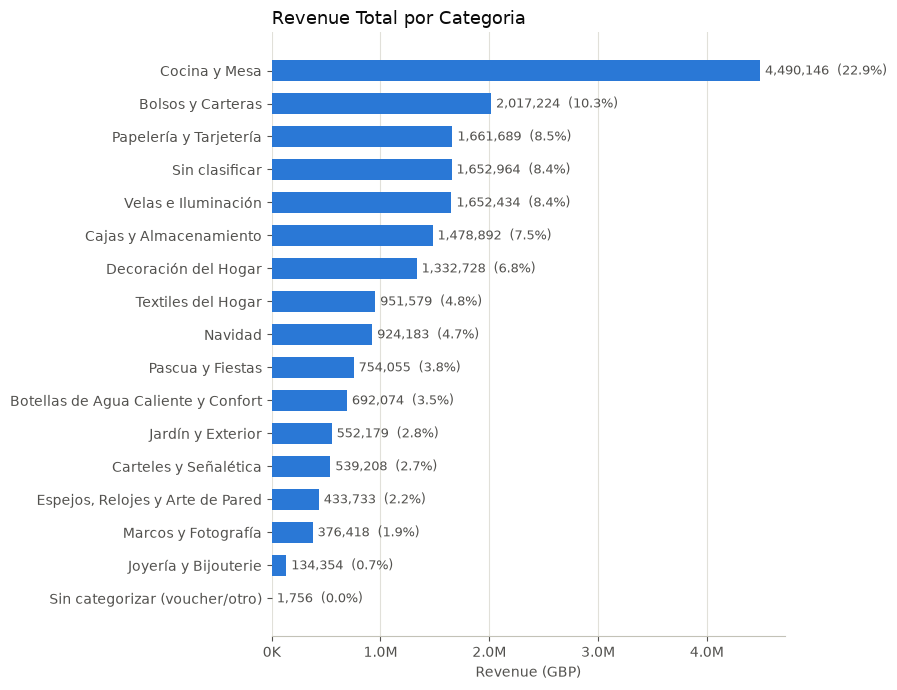

In [193]:
import matplotlib.ticker as mticker

orden = resumen_categoria.index.tolist()
colores = [COLOR_MUTED if cat.startswith("Sin categorizar") else COLOR_SEQ for cat in orden]

fig, ax = plt.subplots(figsize=(9, 7))
barras = ax.barh(orden, resumen_categoria["revenue"], color=colores, height=0.65, zorder=3)
ax.invert_yaxis()

ax.set_xlabel("Revenue (GBP)", color=COLOR_INK_SEC)
ax.set_title("Revenue Total por Categoria", color=COLOR_INK, fontsize=13, loc="left")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)

ax.tick_params(colors=COLOR_INK_SEC)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(COLOR_AXIS)
ax.grid(axis="x", color=COLOR_GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

for barra, valor, part in zip(barras, resumen_categoria["revenue"], resumen_categoria["participacion"]):
    ax.text(
        valor + resumen_categoria["revenue"].max() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:,.0f}  ({part:.1%})",
        va="center", ha="left", fontsize=9, color=COLOR_INK_SEC,
    )

plt.tight_layout()
plt.show()

## 4. Estacionalidad mensual por Categoría

In [194]:
df_con_categoria["invoice_date"] = pd.to_datetime(df_con_categoria["invoice_date"])
df_con_categoria["periodo"] = df_con_categoria["invoice_date"].dt.to_period("M").dt.to_timestamp()

CATEGORIAS_DESTACADAS = ["Navidad", "Cocina y Mesa", "Bolsos y Carteras", "Papelería y Tarjetería"]

df_con_categoria["categoria_grafico"] = np.where(
    df_con_categoria["categoria_final"].isin(CATEGORIAS_DESTACADAS),
    df_con_categoria["categoria_final"],
    "Otras categorias",
)

mensual_pivot = (
    df_con_categoria.groupby(["periodo", "categoria_grafico"])["total_price"]
    .sum()
    .unstack("categoria_grafico")
    .fillna(0)
)[CATEGORIAS_DESTACADAS + ["Otras categorias"]]

mensual_pivot

categoria_grafico,Navidad,Cocina y Mesa,Bolsos y Carteras,Papelería y Tarjetería,Otras categorias
periodo,,,,,
2009-12-01,29969.20,171962.08,55343.39,58216.56,482627.30
2010-01-01,1089.72,151922.74,56978.70,34882.23,367492.11
2010-02-01,882.06,128532.50,58558.75,39255.96,310697.42
2010-03-01,1532.57,165916.16,70312.94,66323.60,457663.26
2010-04-01,792.74,154720.65,72006.46,48531.87,370399.84
2010-05-01,1423.77,165688.86,66768.71,49249.00,360455.30
2010-06-01,2415.44,180457.43,88030.43,48527.32,377220.65
2010-07-01,6960.24,162541.22,70064.38,41662.67,351850.91
2010-08-01,16272.37,155725.94,81606.12,54936.48,365651.98


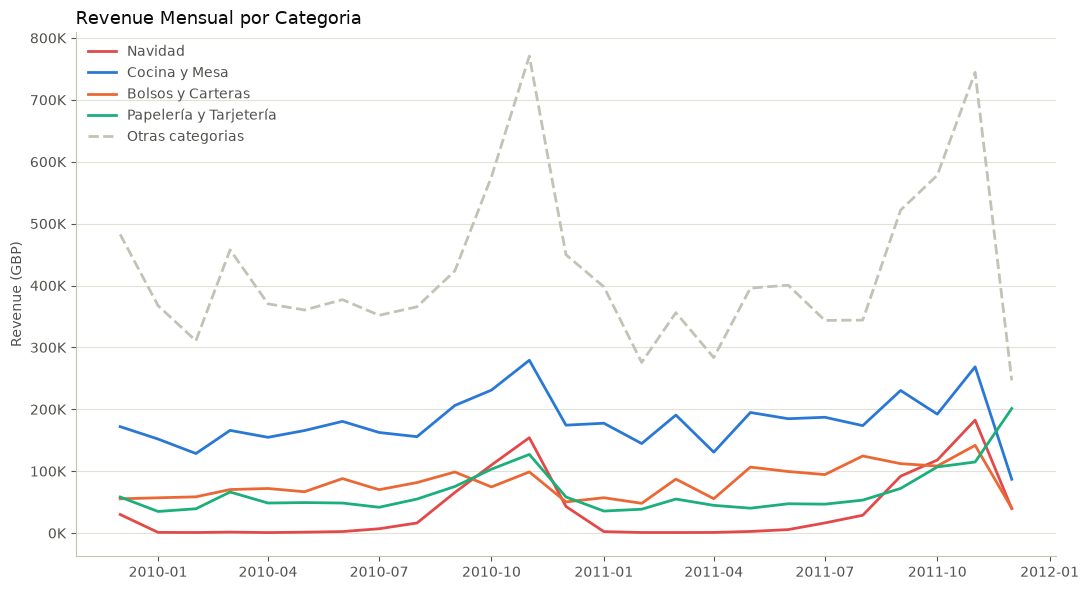

In [195]:
COLORES_CATEGORICOS = ["#e34948", "#2a78d6", "#eb6834", "#1baf7a"]  # Navidad en rojo (slot 8), resto en orden fijo
COLOR_OTRAS = "#c3c2b7"

fig, ax = plt.subplots(figsize=(11, 6))

for cat, color in zip(CATEGORIAS_DESTACADAS, COLORES_CATEGORICOS):
    ax.plot(mensual_pivot.index, mensual_pivot[cat], color=color, linewidth=2, label=cat)

ax.plot(
    mensual_pivot.index, mensual_pivot["Otras categorias"],
    color=COLOR_OTRAS, linewidth=2, linestyle="--", label="Otras categorias", zorder=1,
)

ax.set_title("Revenue Mensual por Categoria", color=COLOR_INK, fontsize=13, loc="left")
ax.set_ylabel("Revenue (GBP)", color=COLOR_INK_SEC)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

ax.tick_params(colors=COLOR_INK_SEC)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(COLOR_AXIS)
ax.spines["bottom"].set_color(COLOR_AXIS)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.legend(frameon=False, loc="upper left", labelcolor=COLOR_INK_SEC)

plt.tight_layout()
plt.show()

In [196]:
print(f"Ultima fecha en el dataset: {df_con_categoria['invoice_date'].max()}")

dias_por_mes = df_con_categoria.groupby("periodo")["invoice_date"].agg(["min", "max"])
dias_por_mes["dias_cubiertos"] = (dias_por_mes["max"] - dias_por_mes["min"]).dt.days + 1
dias_por_mes.tail(3)

Ultima fecha en el dataset: 2011-12-09 00:00:00


,min,max,dias_cubiertos
periodo,,,
2011-10-01,2011-10-02,2011-10-31,30
2011-11-01,2011-11-01,2011-11-30,30
2011-12-01,2011-12-01,2011-12-09,9


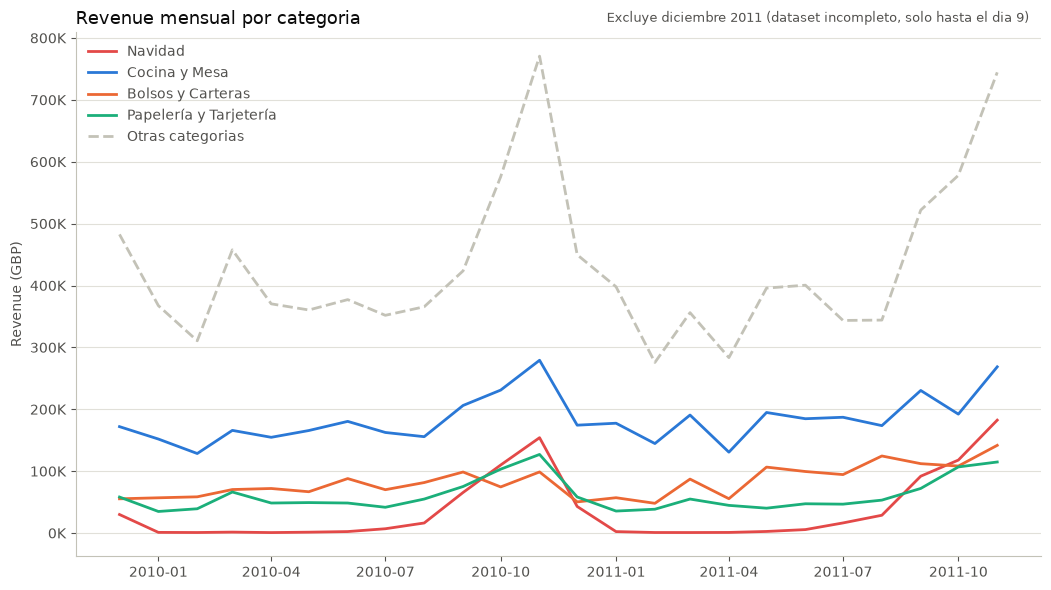

In [197]:
mensual_pivot_completo = mensual_pivot.iloc[:-1]  # excluye el ultimo mes (2011-12, parcial)

fig, ax = plt.subplots(figsize=(11, 6))

for cat, color in zip(CATEGORIAS_DESTACADAS, COLORES_CATEGORICOS):
    ax.plot(mensual_pivot_completo.index, mensual_pivot_completo[cat], color=color, linewidth=2, label=cat)

ax.plot(
    mensual_pivot_completo.index, mensual_pivot_completo["Otras categorias"],
    color=COLOR_OTRAS, linewidth=2, linestyle="--", label="Otras categorias", zorder=1,
)

ax.set_title("Revenue mensual por categoria", color=COLOR_INK, fontsize=13, loc="left")
ax.text(
    0.55, 1.02, "Excluye diciembre 2011 (dataset incompleto, solo hasta el dia 9)",
    transform=ax.transAxes, fontsize=9, color=COLOR_INK_SEC,
)
ax.set_ylabel("Revenue (GBP)", color=COLOR_INK_SEC)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

ax.tick_params(colors=COLOR_INK_SEC)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(COLOR_AXIS)
ax.spines["bottom"].set_color(COLOR_AXIS)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.legend(frameon=False, loc="upper left", labelcolor=COLOR_INK_SEC)

plt.tight_layout()
plt.show()

## 5. Mix de categorías por país

In [198]:
df_con_categoria["region"] = np.where(
    df_con_categoria["country"] == "United Kingdom", "Reino Unido", "Resto del mundo"
)

revenue_region_categoria = df_con_categoria.groupby(["region", "categoria_final"])["total_price"].sum()
revenue_region_total = df_con_categoria.groupby("region")["total_price"].sum()

mix_region = (
    revenue_region_categoria
    .div(revenue_region_total, level="region")
    .reset_index(name="participacion")
)

mix_pivot = mix_region.pivot(index="categoria_final", columns="region", values="participacion").fillna(0)
mix_pivot["diferencia"] = mix_pivot["Resto del mundo"] - mix_pivot["Reino Unido"]
mix_pivot = mix_pivot.sort_values("diferencia")

mix_pivot

region,Reino Unido,Resto del mundo,diferencia
categoria_final,,,
Decoración del Hogar,0.072582,0.039802,-0.032780
Textiles del Hogar,0.051658,0.029403,-0.022254
Botellas de Agua Caliente y Confort,0.038393,0.016523,-0.021870
Velas e Iluminación,0.087060,0.066689,-0.020371
Marcos y Fotografía,0.021310,0.006455,-0.014855
Navidad,0.048915,0.035974,-0.012941
Carteles y Señalética,0.028612,0.020559,-0.008053
Jardín y Exterior,0.029140,0.022003,-0.007136
Bolsos y Carteras,0.103591,0.097299,-0.006292


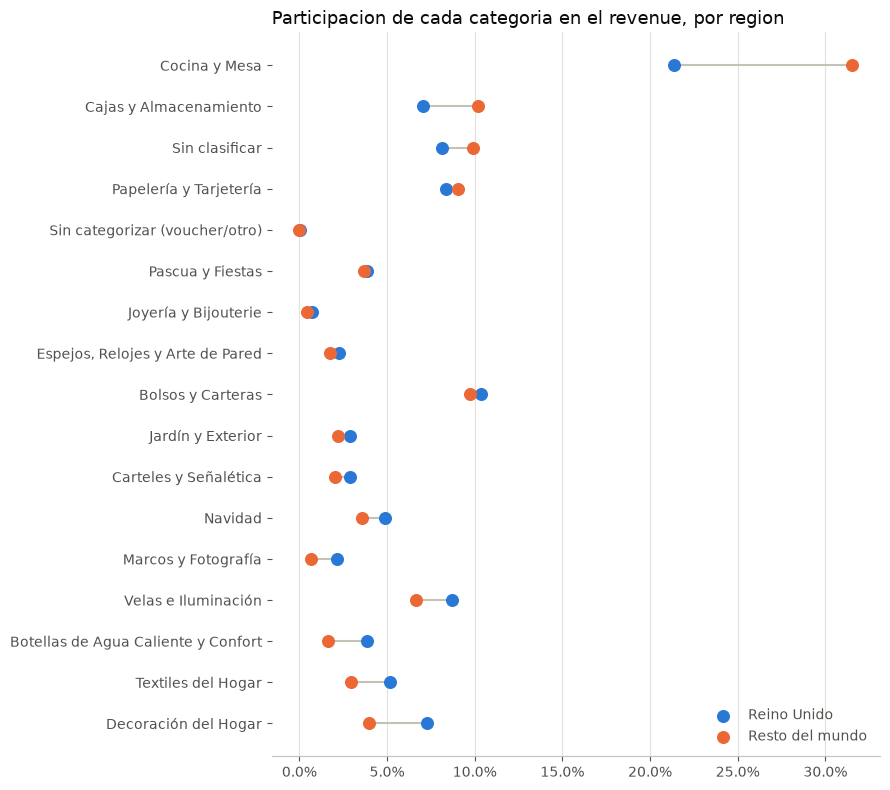

In [199]:
COLOR_UK = "#2a78d6"     # slot 1
COLOR_RESTO = "#eb6834"  # slot 2

fig, ax = plt.subplots(figsize=(9, 8))
y_pos = np.arange(len(mix_pivot))

ax.hlines(y_pos, mix_pivot["Reino Unido"], mix_pivot["Resto del mundo"], color=COLOR_AXIS, linewidth=1.5, zorder=1)
ax.scatter(mix_pivot["Reino Unido"], y_pos, color=COLOR_UK, s=70, zorder=3, label="Reino Unido")
ax.scatter(mix_pivot["Resto del mundo"], y_pos, color=COLOR_RESTO, s=70, zorder=3, label="Resto del mundo")

ax.set_yticks(y_pos)
ax.set_yticklabels(mix_pivot.index)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax.set_title("Participacion de cada categoria en el revenue, por region", color=COLOR_INK, fontsize=13, loc="left")
ax.tick_params(colors=COLOR_INK_SEC)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(COLOR_AXIS)
ax.grid(axis="x", color=COLOR_GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.legend(frameon=False, loc="lower right", labelcolor=COLOR_INK_SEC)

plt.tight_layout()
plt.show()

## 6. Top productos por categoría

In [200]:
top_por_categoria = (
    catalogo.sort_values("revenue_total", ascending=False)
    .groupby("categoria_final")
    .head(5)
    .sort_values(["categoria_final", "revenue_total"], ascending=[True, False])
    [["categoria_final", "description_clean", "revenue_total", "unidades_totales"]]
    .set_index(["categoria_final", "description_clean"])
)

top_por_categoria.style.format({"revenue_total": "{:,.0f}", "unidades_totales": "{:,.0f}"})

### 7. Preparación de datos para Power BI (esquema estrella)

### 7.1 Tabla de Hechos (fact_ventas)

In [201]:
fact_ventas = transacciones[[
    "invoice", "stock_code", "quantity", "invoice_date", "invoice_datetime",
    "unit_price", "customer_id", "country", "canceled", "total_price",
]].copy()

fact_ventas["invoice_date"] = pd.to_datetime(fact_ventas["invoice_date"])
fact_ventas["region"] = np.where(fact_ventas["country"] == "United Kingdom", "Reino Unido", "Resto del mundo")

fact_ventas.to_csv("data/processed/fact_ventas.csv", index=False, sep=";", decimal=",")
print(f"fact_ventas: {fact_ventas.shape}")
fact_ventas.head()

fact_ventas: (1003417, 11)


,invoice,stock_code,quantity,invoice_date,invoice_datetime,unit_price,customer_id,country,canceled,total_price,region
0,489434,85048,12,2009-12-01,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,Reino Unido
1,489434,79323P,12,2009-12-01,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,Reino Unido
2,489434,79323W,12,2009-12-01,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,Reino Unido
3,489434,22041,48,2009-12-01,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,Reino Unido
4,489434,21232,24,2009-12-01,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,Reino Unido


### 7.2 Dimensión de producto (dim_producto)

In [202]:
dim_producto = catalogo[["stock_code", "description_clean", "categoria_final"]].copy()
dim_producto.to_csv("data/processed/dim_producto.csv", index=False, sep=";")
print(f"dim_producto: {dim_producto.shape}")
dim_producto.head()

dim_producto: (4724, 3)


,stock_code,description_clean,categoria_final
0,10002,INFLATABLE POLITICAL GLOBE,Sin clasificar
1,10002R,ROBOT PENCIL SHARPNER,Papelería y Tarjetería
2,10080,GROOVY CACTUS INFLATABLE,Velas e Iluminación
3,10109,BENDY COLOUR PENCILS,Papelería y Tarjetería
4,10120,DOGGY RUBBER,Papelería y Tarjetería


### 7.3 Dimensión de fechas (dim_fechas)

In [203]:
fechas_unicas = fact_ventas["invoice_date"].drop_duplicates().sort_values()

dim_fecha = pd.DataFrame({"fecha": fechas_unicas})
dim_fecha["anio"] = dim_fecha["fecha"].dt.year
dim_fecha["mes"] = dim_fecha["fecha"].dt.month
dim_fecha["mes_nombre"] = dim_fecha["fecha"].dt.strftime("%B")
dim_fecha["trimestre"] = dim_fecha["fecha"].dt.quarter
dim_fecha["anio_mes"] = dim_fecha["fecha"].dt.strftime("%Y-%m")
dim_fecha["mes_completo"] = dim_fecha["anio_mes"] != dim_fecha["anio_mes"].max()

dim_fecha.to_csv("data/processed/dim_fecha.csv", index=False, sep=";")
print(f"dim_fecha: {dim_fecha.shape}")
dim_fecha.tail()

dim_fecha: (604, 7)


,fecha,anio,mes,mes_nombre,trimestre,anio_mes,mes_completo
986191,2011-12-05,2011,12,December,4,2011-12,False
991433,2011-12-06,2011,12,December,4,2011-12,False
994631,2011-12-07,2011,12,December,4,2011-12,False
996980,2011-12-08,2011,12,December,4,2011-12,False
1001806,2011-12-09,2011,12,December,4,2011-12,False
